<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/k_brazos/softmax_bernoulli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* Este notebook presenta un estudio detallado del rendimiento del algoritmo **Softmax** en un problema de k-armed bandit.

Se comparan diferentes configuraciones del parámetro de temperatura $\tau$ (tau) para analizar el compromiso entre exploración y explotación en el contexto de la distribución de recompensa **Bernoulli**.

    Authors: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín
    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
    Date: 2026/02/28

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html

## Preparación del entorno

Importamos las librerías necesarias y copiamos nuestro repositorio del proyecto.

In [ ]:
!git clone https://github.com/angelms2003/FernandezMartinezPolo-EML-RL.git

Cloning into 'FernandezMartinezPolo-EML-RL'...
remote: Enumerating objects: 632, done.
remote: Counting objects: 100% (281/281), done.
remote: Compressing objects: 100% (204/204), done.
remote: Total 632 (delta 157), reused 164 (delta 77), pack-reused 351 (from 1)
Receiving objects: 100% (632/632), 34.47 MiB | 10.96 MiB/s, done.
Resolving deltas: 100% (354/354), done.


In [ ]:
%cd FernandezMartinezPolo-EML-RL/k_brazos

/content/FernandezMartinezPolo-EML-RL/k_brazos


In [ ]:
#Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('./src')

# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, Softmax
from arms import ArmBernoulli, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', './src']


## Diseño del experimento

En este notebook se analiza un problema de bandido multi-brazo de 10 brazos, donde cada brazo sigue una distribución de Bernoulli con probabilidad de éxito $p \in (0, 1)$. Se implementan cuatro configuraciones del algoritmo Softmax, utilizando distintos valores del parámetro de temperatura $\tau$.

A diferencia de estrategias como $\varepsilon$-Greedy, donde en cada paso se elige una acción aleatoria con probabilidad $\varepsilon$ y, en caso contrario, se selecciona la acción con mayor recompensa media estimada, el algoritmo Softmax asigna una probabilidad de selección a cada acción de forma proporcional a su valor estimado. En concreto, en cada iteración se selecciona la acción $a$ con probabilidad:

$$
P_t(a) = \frac{e^{Q_t(a) / \tau}}{\sum_{b=1}^k e^{Q_t(b) / \tau}}
$$

donde $Q_t(a)$ representa la estimación actual de la recompensa media de la acción $a$, y $\tau > 0$ es el parámetro de temperatura que controla el equilibrio entre exploración y explotación.

Podemos interpretar el efecto del parámetro $\tau$ sobre el comportamiento del agente de la siguiente manera: con valores altos de $\tau$, las diferencias entre los $Q_t(a)$ se diluyen y la distribución de probabilidad se aproxima a la uniforme, fomentando la exploración. Con valores bajos, las diferencias se amplifican y el algoritmo tiende a seleccionar casi siempre la acción con mayor valor estimado, comportándose de forma similar a una política greedy.

Es importante calibrar el valor de $\tau$ en relación con la escala de las recompensas del entorno, puesto que, como hemos comprobado empíricamente, valores desproporcionadamente pequeños o grandes respecto a las diferencias reales entre brazos producen comportamientos de sobreexplotación o sobreexploración extrema, desvirtuando los experimentos. En el caso de brazos de Bernoulli, las recompensas son estrictamente binarias ($0$ o $1$), por lo que las estimaciones $Q_t(a)$ están acotadas en el intervalo $[0, 1]$. Esto significa que la diferencia absoluta entre el mejor brazo y un brazo promedio es mucho menor que las diferencias que se observan en los otros experimentos de softmax de esta práctica. Por lo tanto, es necesario utilizar temperaturas mucho menores para que la distribución de probabilidad pueda discriminar entre los brazos correctamente, y el experimento esté bien planteado.

Por ello, los cuatro valores seleccionados ($\tau = 0.01$, $\tau = 0.05$, $\tau = 0.1$ y $\tau = 0.2$) se han elegido de forma que sean acordes a la escala del entorno Bernoulli y cubran varios regímenes cualitativamente distintos, desde una política casi greedy ($\tau = 0.01$) hasta una exploración más amplia ($\tau = 0.2$).

El interés de este experimento reside en que el algoritmo no utiliza información sobre el número de veces que se ha seleccionado cada brazo para guiar la exploración, sino que la probabilidad de selección depende únicamente de las estimaciones de valor $Q_t(a)$. Esto lo hace especialmente sensible a la calidad de dichas estimaciones en las primeras iteraciones, cuando aún son ruidosas. En el caso de Bernoulli, esta sensibilidad es incluso más marcada, ya que las primeras recompensas observadas son $0$ o $1$, por lo que un brazo con probabilidad alta puede recibir un $0$ inicial y quedar penalizado durante muchas iteraciones. Estudiar su comportamiento con distintos valores de $\tau$ permite analizar cómo gestiona este algoritmo la incertidumbre inicial y en qué medida logra identificar y explotar el brazo óptimo a lo largo del tiempo.

### Configuración del Experimento
Cada política se evalúa a lo largo de 2000 iteraciones, y todo el experimento se repite 500 veces de forma independiente. En cada iteración se calcula la media de las recompensas obtenidas considerando esas 500 ejecuciones.

La razón por la que se usan 2000 iteraciones, es que se requiere un horizonte temporal suficientemente largo para observar el comportamiento asintótico de los algoritmos y obtener estimaciones estables del rechazo acumulado.

La comparación entre algoritmos se realiza utilizando varias métricas: recompensa media, proporción media de selecciones óptimas, rechazo acumulado medio y ganancia y número de selecciones promedio por brazo.

In [ ]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    regrets = np.zeros((len(algorithms), steps)) # Matriz para almacenar los rechazos promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    arm_stats = [{'mean_rewards': np.zeros(bandit.k), 'selections': np.zeros(bandit.k)} for _ in algorithms] #Para las arm stats

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        sum_current_run_expected_value = np.zeros(len(algorithms)) # Aquí se almacena el valor esperado acumulado para cada algoritmo de esta run. Necesario para calcular el rechazo

        for idx, algo in enumerate(algorithms):
            for step in range(steps):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.

                arm_stats[idx]['mean_rewards'][chosen_arm] += reward # Actualizar la ganancia del brazo seleccionado por el algoritmo.
                arm_stats[idx]['selections'][chosen_arm] += 1 # Actualizar el número de selecciones del brazo seleccionado por el algoritmo.

                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                # Modificar optimal_selections cuando el brazo elegido se corresponde con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                # Si el step actual es 0, el valor esperado acumulado se inicializa con el valor esperado del brazo
                # elegido actualmente. Si no, se suma el valor esperado del brazo actual al valor acumulado
                if step == 0:
                    sum_current_run_expected_value[idx] = bandit.get_expected_value(chosen_arm)
                else:
                    sum_current_run_expected_value[idx] = sum_current_run_expected_value[idx] + bandit.get_expected_value(chosen_arm)

                regrets[idx, step] += (step+1)*bandit.get_expected_value(optimal_arm) - sum_current_run_expected_value[idx]

    rewards /= runs
    regrets /= runs

    # Calcular el porcentaje de selecciones óptimas
    optimal_selections = optimal_selections*100/runs

    for stat in arm_stats:
      stat['mean_rewards'] /= runs
      stat['selections'] /= runs

    return rewards, regrets, optimal_selections, arm_stats

Definimos los parámetros del experimento seleccionados en la fase de diseño experimental:

In [ ]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 2000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")


# Algoritmos a comparar (distintas temperaturas, adaptadas a la escala Bernoulli)
algorithms_bernoulli = [
    Softmax(k=k, tau=0.01),
    Softmax(k=k, tau=0.05),
    Softmax(k=k, tau=0.1),
    Softmax(k=k, tau=0.2)
]

# Ejecutar
rewards_b, regrets_b, optimal_b, arm_stats_b = run_experiment(bandit, algorithms_bernoulli, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.37), ArmBernoulli(p=0.95), ArmBernoulli(p=0.73), ArmBernoulli(p=0.60), ArmBernoulli(p=0.16), ArmBernoulli(p=0.16), ArmBernoulli(p=0.06), ArmBernoulli(p=0.87), ArmBernoulli(p=0.60), ArmBernoulli(p=0.71)
Optimal arm: 2 with expected reward=0.9507143064099162


Ahora exportamos los resultados para poder luego generar una gráfica conjuntamente con los otros algoritmos.

In [ ]:
import os

# Create a directory to store the exported data
output_dir = 'exported_data'
os.makedirs(output_dir, exist_ok=True)

# Export data for Bernoulli Distribution
np.savez(os.path.join(output_dir, 'softmax_bernoulli_data.npz'),
         rewards=rewards_b,
         regrets=regrets_b,
         optimal_selections=optimal_b)
print(f"Bernoulli experiment data saved to {os.path.join(output_dir, 'softmax_bernoulli_data.npz')}")

Bernoulli experiment data saved to exported_data/softmax_bernoulli_data.npz


## Visualización de los resultados

#### Recompensa promedio

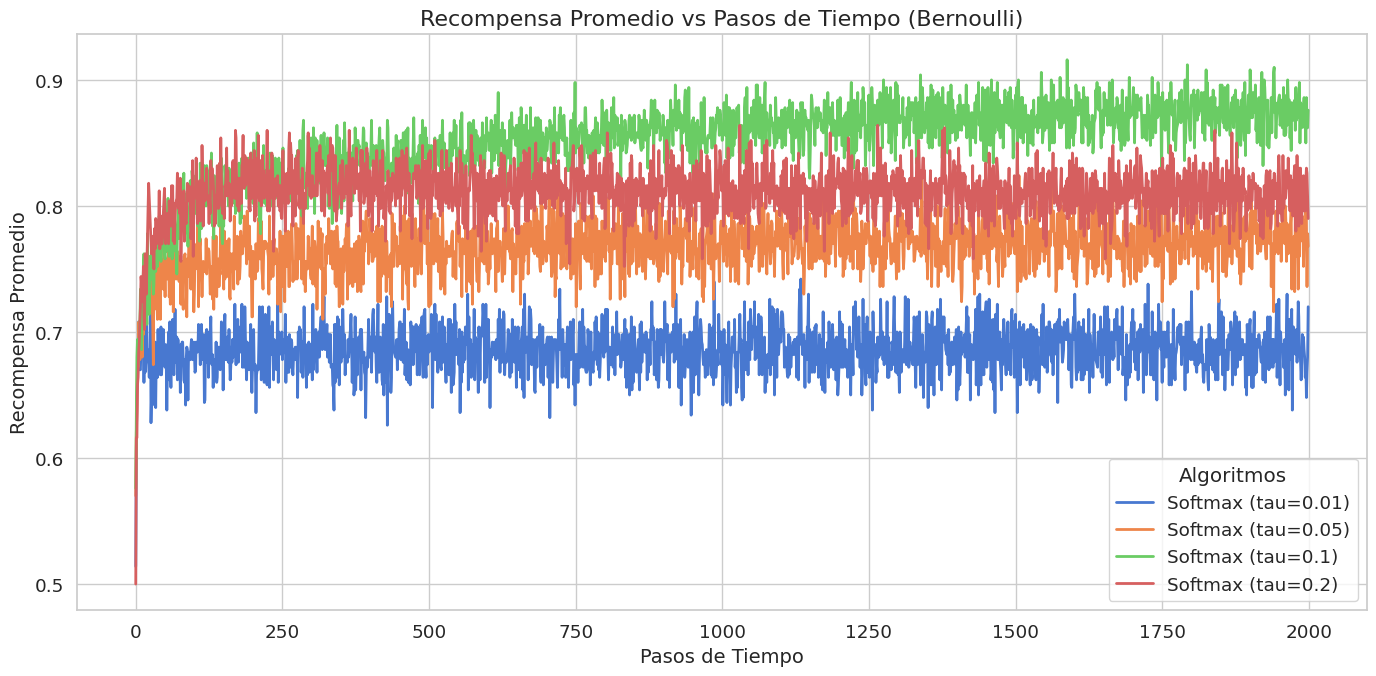

In [ ]:
plot_average_rewards(steps, rewards_b, algorithms_bernoulli, "Bernoulli")

La gráfica compara el comportamiento de las distintas configuraciones del algoritmo **Softmax** en el entorno Bernoulli. En el eje **x** aparecen los **pasos de tiempo**, mientras que en el eje **y** se representa la **recompensa promedio** obtenida por cada política a lo largo del proceso de aprendizaje.

##### **Interpretación de las líneas del gráfico**

Cada una de las cuatro líneas del gráfico se corresponde con una configuración distinta del parámetro de temperatura, y la estrategia que representa según nuestro diseño experimental:

- **Azul ($\tau = 0.01$):** Representa la estrategia más explotadora. Con una temperatura extremadamente baja, las diferencias entre los valores estimados $Q_t(a)$ se amplifican de forma muy agresiva, por lo que el algoritmo colapsa muy rápido hacia la acción con mayor estimación inicial, sin apenas explorar.
- **Naranja ($\tau = 0.05$):** Representa una estrategia moderadamente explotadora. La temperatura es lo suficientemente baja como para dar preferencia clara a las mejores acciones, pero permite cierta exploración que ayuda a corregir estimaciones iniciales erróneas.
- **Verde ($\tau = 0.1$):** Representa una temperatura intermedia dentro de la escala Bernoulli, ofreciendo un equilibrio entre exploración y explotación.
- **Roja ($\tau = 0.2$):** Representa la estrategia más exploradora del conjunto. Aunque $\tau = 0.2$ podría parecer un valor bajo en términos absolutos, en el contexto de recompensas acotadas en $[0, 1]$ resulta suficiente para diluir las diferencias entre brazos y producir una exploración amplia.

##### **Evolución de la recompensa promedio**

El gráfico muestra diferencias apreciables entre las 4 configuraciones estudiadas, con una separación clara en diferentes niveles de rendimiento. Para interpretar los resultados correctamente, cabe recordar que el brazo óptimo tiene una recompensa esperada de $0.95$.

La línea verde ($\tau = 0.1$) es la que mejor rendimiento obtiene con diferencia, situándose en torno a $0.87$ hacia la mitad del experimento, aunque a diferencia de otras configuraciones no llega a estabilizarse por completo. Mantiene una tendencia de crecimiento lento pero sostenido durante toda la ejecución, lo que sugiere que el algoritmo sigue mejorando sus estimaciones progresivamente. A continuación, la línea roja ($\tau = 0.2$) alcanza valores cercanos a $0.82$, mostrando también crecimiento inicial pero convergiendo a un nivel notablemente inferior. La línea naranja ($\tau = 0.05$) se sitúa ligeramente por debajo, estabilizándose alrededor de $0.79$. Por último, la línea azul ($\tau = 0.01$) muestra el peor resultado, ya que se congela en torno a $0.70$ prácticamente desde el inicio, sin ninguna mejora apreciable a lo largo de las 2000 iteraciones.

El resultado más reseñable es que la estrategia con temperatura intermedia ($\tau = 0.1$) supera a todas las demás. Se observa además que todas las configuraciones presentan oscilaciones elevadas y persistentes a lo largo de todo el experimento, más pronunciadas que en los otros experimentos de Softmax realizados. Esto se debe a la naturaleza binaria de las recompensas de Bernoulli, que introduce una varianza clara en cada observación individual y se traslada directamente a la recompensa promedio de cada paso.

En el entorno Bernoulli, donde las primeras recompensas son $0$ o $1$, un brazo con probabilidad alta puede recibir un $0$ inicial por simple aleatoriedad y quedar descartado de forma prácticamente permanente.

Cabe destacar que la mejor configuración ($\tau = 0.1$) se sitúa a menos de $0.1$ puntos por debajo del óptimo teórico ($0.95$), lo que representa un rendimiento proporcionalmente mejor que el observado en los otros dos experimentos de Softmax realizados. El resto de configuraciones acumulan diferencias de entre $0.13$ y $0.25$ puntos respecto al óptimo, lo que pone de manifiesto la alta sensibilidad del algoritmo al parámetro de temperatura también en este entorno.

#### Porcentaje de selección de la acción óptima

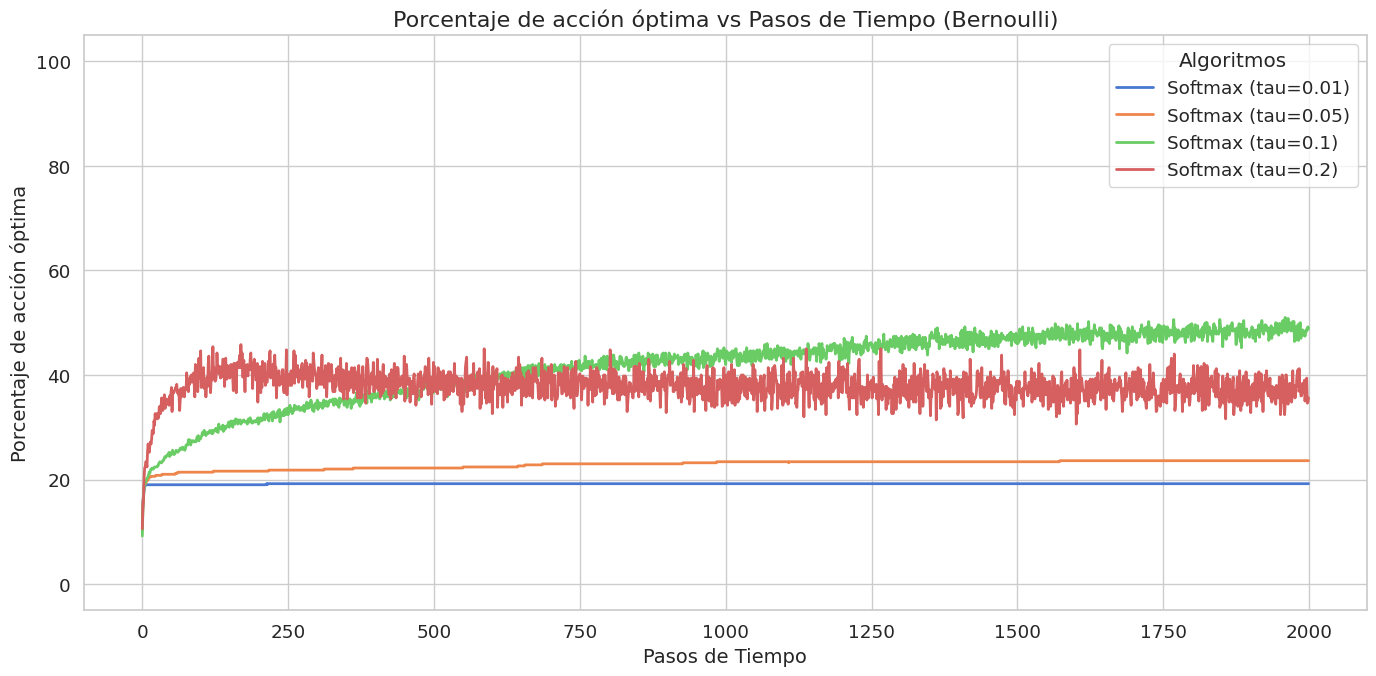

In [ ]:
plot_optimal_selections(steps, optimal_b, algorithms_bernoulli, "Bernoulli")

En el eje **x** de la gráfica se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **porcentaje de veces que se selecciona la acción óptima**.

**Los colores del gráfico son totalmente equivalentes a los de la gráfica anterior.**

##### **Evolución del porcentaje de acción óptima**

Los resultados de esta gráfica son llamativos, ya que los porcentajes de selección óptima son notablemente bajos para todas las configuraciones del algoritmo estudiadas.

La línea verde ($\tau = 0.1$) es la única que muestra una tendencia de mejora sostenida a lo largo del experimento, creciendo desde aproximadamente el $22\%$ hasta situarse en torno al $48\text{-}50\%$ al final de las 2000 iteraciones, aunque sin llegar a converger completamente. La línea roja ($\tau = 0.2$) se estabiliza alrededor del $38\text{-}42\%$ con oscilaciones constantes, lo que refleja la exploración continua característica de temperaturas más altas. Esto podemos interpretarlo como que el algoritmo identifica parcialmente el brazo óptimo pero sigue distribuyendo selecciones entre otros brazos con frecuencia. Las líneas naranja ($\tau = 0.05$) y azul ($\tau = 0.01$) se mantienen prácticamente planas durante todo el experimento, en torno al $23\%$ y al $19\%$ respectivamente.

Es interesante observar que, a diferencia de la gráfica de recompensa promedio donde las cuatro configuraciones mostraban una separación más clara en cuatro niveles, aquí las líneas se agrupan en dos bloques: las temperaturas más altas ($\tau = 0.1$ y $\tau = 0.2$) que consiguen porcentajes de selección óptima crecientes o moderados, y las temperaturas más bajas ($\tau = 0.01$ y $\tau = 0.05$) que quedan estancadas desde las primeras iteraciones.

En particular, podemos destacar que $\tau = 0.05$ presentaba un resultado en la gráfica de recompensa muy similar al de $\tau = 0.2$, mientras que en la gráfica de porcentaje de acción óptima es claramente inferior. Esto parece indicar que dicha configuración no selecciona mayoritariamente el brazo óptimo, pero sí consigue concentrar sus selecciones en un conjunto reducido de brazos con probabilidades de éxito altas, lo que eleva la recompensa promedio sin identificar el óptimo global.


Otro aspecto evidente en la gráfica es la diferencia de variabilidad entre configuraciones: las temperaturas altas presentan oscilaciones mucho más pronunciadas y persistentes, mientras que las temperaturas bajas muestran líneas prácticamente planas. Esto lo explicamos porque con temperaturas bajas el algoritmo queda bloqueado desde las primeras iteraciones en un brazo concreto, de modo que su comportamiento se vuelve determinista y estable, aunque subóptimo.



#### Rechazo acumulado

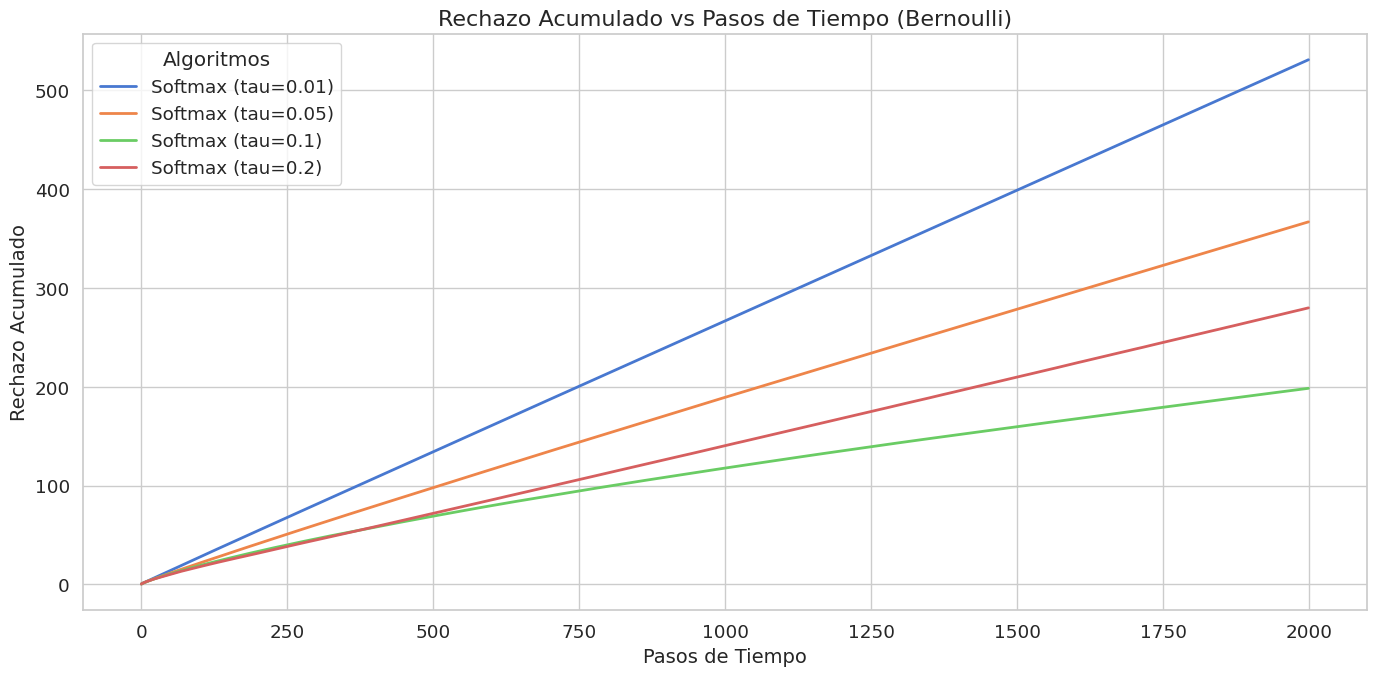

In [ ]:
plot_regret(steps, regrets_b, algorithms_bernoulli, "Bernoulli")

En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **rechazo acumulado**.

**Los colores del gráfico son totalmente equivalentes a los de la gráfica anterior.**

##### **Evolución global del rechazo acumulado**

Un aspecto destacable es que durante los primeros 500 pasos aproximadamente las cuatro curvas crecen de forma muy similar y prácticamente superpuesta, lo que indica que en la fase inicial todos los algoritmos cometen un nivel de error comparable mientras construyen sus estimaciones. Es a partir de ese punto cuando las trayectorias se separan de forma progresiva, evidenciando que las configuraciones con temperatura mejor calibrada comienzan a beneficiarse de sus estimaciones mejoradas.

La línea verde ($\tau = 0.1$) obtiene el mejor resultado ($\approx 200$), con una tendencia claramente sublineal cuya pendiente se reduce de forma progresiva, lo que indica que el algoritmo aprende y reduce la frecuencia de selecciones subóptimas conforme acumula experiencia. La línea roja ($\tau = 0.2$) alcanza el segundo mejor resultado ($\approx 280$), mostrando también cierta curvatura sublineal aunque menos pronunciada, consecuencia de la exploración más amplia que mantiene durante todo el horizonte. La línea naranja ($\tau = 0.05$) presenta un resultado intermedio ($\approx 370$) con un crecimiento prácticamente lineal: a pesar de obtener una recompensa promedio razonablemente alta, la incapacidad de corregir estimaciones iniciales erróneas se traduce en un rechazo que se acumula de forma constante. Por último, la línea azul ($\tau = 0.01$) muestra el peor resultado ($\approx 530$), con la pendiente más pronunciada y un crecimiento estrictamente lineal, coherente con lo observado en las métricas anteriores.

Estos resultados son especialmente relevantes en comparación con los otros dos experimentos de Softmax realizados: mientras que allí concluimos que el Softmax con $\tau$ fijo presentaba limitaciones estructurales evidenciadas por el crecimiento lineal del rechazo para todas las configuraciones, en el entorno Bernoulli la mejor configuración ($\tau = 0.1$) muestra una tendencia sublineal clara, lo que indica que una correcta calibración de la temperatura respecto a la escala de recompensas permite al algoritmo un aprendizaje efectivo y sostenido.

### Ganancia promedio y número de selecciones por brazo

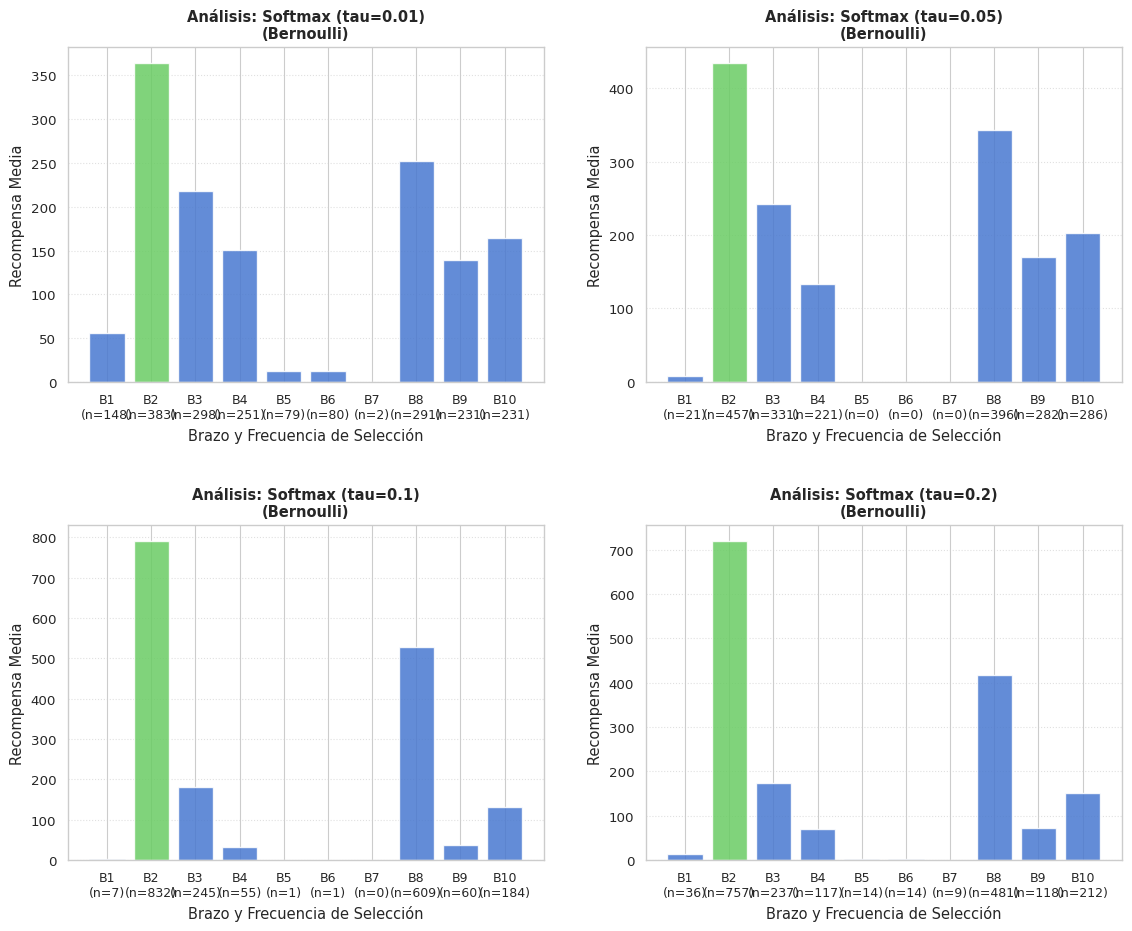

In [ ]:
plot_arm_statistics(arm_stats_b, algorithms_bernoulli, k, optimal_arm, "Bernoulli")

La imagen muestra cuatro gráficos de barras, en los que el eje x representa cada uno de los brazos del bandido, indicando entre paréntesis el número medio de selecciones por brazo a lo largo de las 500 ejecuciones, y en el eje y se muestra la ganancia media obtenida de cada brazo. La barra del brazo óptimo (B2, con $p = 0.95$) se muestra en verde para diferenciarla del resto.

Las cuatro gráficas reflejan de forma clara todo lo que hemos observado en el análisis de las métricas anteriores. Para $\tau = 0.1$, las selecciones se concentran mayoritariamente en el brazo óptimo B2 ($n = 832$) y en el segundo mejor brazo B8 ($n = 609$, con $p = 0.87$), con una presencia residual del resto, lo que es coherente con el mejor rendimiento global que esta configuración mostró en todas las métricas. Para $\tau = 0.2$, la distribución es similar aunque algo más repartida, reflejando la exploración más amplia que sucece con esta temperatura. Para $\tau = 0.05$, el brazo óptimo B2 recibe el mayor número de selecciones ($n = 457$), pero B8 ($n = 396$), B3 ($n = 331$), B10 ($n = 286$) y B9 ($n = 282$) acumulan un número comparable de selecciones, lo que explica por qué esta configuración obtenía una recompensa promedio alta pero un porcentaje de selección óptima bajo. Finalmente, $\tau = 0.01$ presenta la distribución más dispersa de todas, con selecciones repartidas entre todos los brazos, incluyendo los peores (B5 con $n = 79$ y B6 con $n = 80$), lo que confirma el comportamiento observado y el mal rendimiento.

Es importante tener en cuenta que estas gráficas agregan el comportamiento a lo largo de todas las ejecuciones y todos los pasos de tiempo. Por ello, una distribución de selecciones repartida entre varios brazos no implica que el algoritmo haya explorado de forma inteligente, sino que en distintas ejecuciones ha quedado atrapado en distintos subóptimos.

Estos resultados son coherentes con la intuición teórica sobre el comportamiento del algoritmo que habíamos propuesto en el diseño del experimento.

## Conclusiones

El resultado más destacable del experimento es que el algoritmo Softmax con $\tau$ fijo muestra un rendimiento algo inferior en el entorno Bernoulli respecto al observado en los otros dos algoritmos estudiados en el proyecto con esta misma distribución.

En este sentido, destaca especialmente

La configuración $\tau = 0.1$ es la que mejor se comporta en este entorno concreto, logrando la mayor recompensa promedio ($\approx 0.87$, a menos de $0.1$ puntos del óptimo teórico de $0.95$), el mayor porcentaje de selecciones óptimas y el menor rechazo acumulado ($\approx 200$).

Este resultado demuestra que el rendimiento del Softmax es altamente sensible a la elección de $\tau$ en relación con la escala de las recompensas del entorno. En el entorno Bernoulli la escala reducida de las diferencias entre brazos exige temperaturas proporcionalmente menores a las escogidas en los otros experimentos de softmax.

Los casos extremos ilustran el compromiso exploración-explotación asociado al parámetro de temperatura. Dado que las recompensas son binarias, con valores de $τ$ pequeños un brazo con probabilidad alta puede recibir un $0$ por azar y quedar descartado permanentemente, lo que explica que se aprecie una peor rendimiento evidente de estas configuraciones respecto a las que tienen valores de $\tau$ más grandes.

Pese a los resultados relativamente buenos obtenidos con la temperatura intermedia, al compararlos con los otros dos experimentos de softmax de este proyecto, el rendimiento sigue siendo peor que con los algoritmos $ɛ$-greedy y UCB.

Nuestra hipótesis es que el algoritmo Softmax con temperatura fija tiene una limitación importante que afecta al rendimiento. Como el parámetro $\tau$ no se adapta a medida que las estimaciones mejoran, se impide una convergencia completa, y el "ruido estadístico" de la exploración inicial penaliza mucho el resto de la ejecución, lo que impide alcanzar resultados satisfactorios.

Pese a los malos resultados, el experimento nos ha permitido verificar empíricamente que una correcta calibración de $\tau$ respecto a la escala del entorno es un factor determinante del rendimiento del algoritmo, y estudiar el efecto del parámetro $\tau$ sobre el rendimiento del algoritmo.